# Disaster Tweet Classification: Day 5 Error Analysis

## Goal
Understand *why* the current best model makes mistakes.

## What this notebook does
1. Load the processed training data
2. Recreate the Day 4 winning model
3. Use the same train/validation split
4. Identify false positives and false negatives
5. Inspect examples manually
6. Look for repeated failure patterns
7. Write conclusions for model improvement

## Current best model
- Experiment 002
- Logistic Regression + TF-IDF (1,1)
- Validation F1: 0.7769

In [1]:
print("Imports and Constants")

import os
import warnings
from collections import Counter
from IPython.display import display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_FEATURES = 10000
NGRAM_RANGE = (1, 1)
TOP_N = 20

TRAIN_PROCESSED_PATH = "../outputs/train_processed.csv"
FIGURES_DIR = "../outputs/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

Imports and Constants


In [2]:
print("Load Preprocessed data")

df = pd.read_csv(TRAIN_PROCESSED_PATH, keep_default_na=False)
df["cleaned_text"] = df["cleaned_text"].fillna("").astype(str).str.strip()

print("Shape:", df.shape)
print("Missing cleaned_text:", df["cleaned_text"].isna().sum())
print("Empty cleaned_text:", (df["cleaned_text"] == "").sum())

display(df[["text", "cleaned_text", "target"]].head())

Load Preprocessed data
Shape: (7613, 13)
Missing cleaned_text: 0
Empty cleaned_text: 2


,text,cleaned_text,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquake may allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,resident asked shelter place notified officer evacuation shelter place order expected,1
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfire evacuation order california,1
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo ruby alaska smoke wildfire pours school,1


## Load the Model

In [7]:
print("Create validation split")

X = df["cleaned_text"]
y = df["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("y_val distribution:")
print(y_val.value_counts(normalize=True).round(4))

Create validation split
X_train shape: (6090,)
X_val shape: (1523,)
y_train distribution:
target
0    0.5703
1    0.4297
Name: proportion, dtype: float64
y_val distribution:
target
0    0.5706
1    0.4294
Name: proportion, dtype: float64


In [8]:
print("Load saved model and predict")

import joblib

MODEL_PATH = "../outputs/models/exp_002_logreg_tfidf_unigram.pkl"
best_pipeline = joblib.load(MODEL_PATH)

y_val_pred = best_pipeline.predict(X_val)
y_val_proba = best_pipeline.predict_proba(X_val)[:, 1]

print("Predictions generated successfully.")

Load saved model and predict
Predictions generated successfully.


In [9]:
val_df = df.loc[X_val.index, ["text", "cleaned_text", "target", "keyword", "location"]].copy()
val_df = val_df.rename(columns={"target": "true_label"})
val_df["pred_label"] = y_val_pred
val_df["pred_proba_disaster"] = y_val_proba
val_df["correct"] = val_df["true_label"] == val_df["pred_label"]

display(val_df.head())

,text,cleaned_text,true_label,keyword,location,pred_label,pred_proba_disaster,correct
4863,@TheEconomist Step one: get that mass murderer's portrait off the yuan.,step one get mass murderer portrait yuan,0,mass%20murderer,"Huntsville, AL",0,0.467495,True
1370,Ted Cruz fires back at Jeb &amp; Bush: ÛÏWe lose because of Republicans like Jeb &amp; Mitt.Û [Video] - http://t.co/BFTHaHLCr0,ted cruz fire back jeb bush lose republican like jeb mitt video,0,bush%20fires,Queen Creek AZ,0,0.327372,True
3521,How ÛÏLittle BoyÛ Affected the People In Hiroshima ÛÒ Eyewitness Testimonials http://t.co/mUAnfWcRW9,little boy affected people hiroshima eyewitness testimonial,1,eyewitness,,1,0.770417,True
178,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE CHOICE OF 14 LEZ COMPLIANT | eBay http://t.co/4evTTqPEia,ambulance sprinter automatic frontline vehicle choice lez compliant ebay,0,ambulance,Happily Married with 2 kids,0,0.230639,True
5859,'Cause you play me like a symphony play me till your fingers bleed. I'm your greatest masterpiece. You ruin me??,cause play like symphony play till finger bleed greatest masterpiece ruin,0,ruin,,0,0.136552,True


Confusion Matrix


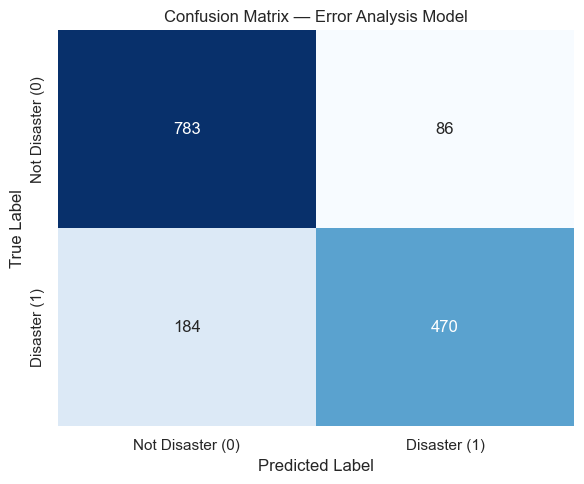

In [10]:
print("Confusion Matrix")

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not Disaster (0)", "Disaster (1)"],
    yticklabels=["Not Disaster (0)", "Disaster (1)"]
)
plt.title("Confusion Matrix — Error Analysis Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [11]:
print("Split Error Groups")
false_positives = val_df[
    (val_df["true_label"] == 0) & (val_df["pred_label"] == 1)
].copy()

false_negatives = val_df[
    (val_df["true_label"] == 1) & (val_df["pred_label"] == 0)
].copy()

true_positives = val_df[
    (val_df["true_label"] == 1) & (val_df["pred_label"] == 1)
].copy()

true_negatives = val_df[
    (val_df["true_label"] == 0) & (val_df["pred_label"] == 0)
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))
print("True positives:", len(true_positives))
print("True negatives:", len(true_negatives))

Split Error Groups
False positives: 86
False negatives: 184
True positives: 470
True negatives: 783


In [12]:
print("sample False Positives")
display(false_positives[["text", "cleaned_text", "keyword", "location"]].head(15))

sample False Positives


,text,cleaned_text,keyword,location
1358,if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings,firefighter acted like cop drive around shooting flamethrower burning building,burning%20buildings,midwest
5267,@TroySlaby22 slicker than an oil spill,slicker oil spill,oil%20spill,
5017,The 19 year old's smug face when Dorret brings out her mudslide Black Forest gateau #priceless #GBBO,year old smug face dorret brings mudslide black forest gateau priceless gbbo,mudslide,London
1673,That sounds about right. Our building will have a thunderstorm inside one day when the air masses collide. https://t.co/2rTQ9QmGPB,sound right building thunderstorm inside one day air mass collide,collide,"Kansas, The Free State! ~ KC"
4004,I hope it rains throughout the whole weekend I hope it floods and the portaloos become sentient.,hope rain throughout whole weekend hope flood portaloos become sentient,floods,"St Austell, Cornwall"
3057,#Sismo M 1.3 - 1km NNE of The Geysers California: Time2015-08-05 23:40:21 UTC2015-08-05 16:40:21 -07:00 a... http://t.co/x6el3ySYcn #CS,sismo km nne geyser california time utc,earthquake,Desde Republica Argentina
2986,Drowning in Actavis suicide,drowning actavis suicide,drowning,Pittsburgh
3749,I See Fire,see fire,fire,
4376,Governor weighs parole for California school bus hijacker http://t.co/7NPBfRzEJL http://t.co/Y0kByy8nce,governor weighs parole california school bus hijacker,hijacker,California
2951,So today I fell off a rock scraped my whole butt and nearly drowned #summer2k15,today fell rock scraped whole butt nearly drowned summer,drowned,


In [13]:
print("Sample False Negatives")
display(false_negatives[["text", "cleaned_text", "keyword", "location"]].head(15))

Sample False Negatives


,text,cleaned_text,keyword,location
6837,Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped miners starring... http://t.co/tyyfG4qQvM,hollywood movie trapped miner released chile hollywood movie trapped miner starring,trapped,
2905,I can't drown my demons they know how to swim,drown demon know swim,drown,Portugal
1956,@XHNews We need these plants in the pacific during the cyclone seasons it would help,need plant pacific cyclone season would help,cyclone,
5020,'It looks like a mudslide' poor thing! ?? #greatbritishbakeoff,look like mudslide poor thing greatbritishbakeoff,mudslide,Birmingham & Bristol
7605,on the flip side I'm at Walmart and there is a bomb and everyone had to evacuate so stay tuned if I blow up or not,flip side walmart bomb everyone evacuate stay tuned blow,,
6818,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day in September there,bomb head explosive decision dat produced dead child dead body trapped tween building day september,trapped,10 Steps Ahead. Cloud 9
6006,I agree with certain cultural appropriation things but honestly if u looked at my house it screams appropriation bc Buddhas and stuff-,agree certain cultural appropriation thing honestly looked house scream appropriation bc buddha stuff,screams,Sheffield/Leeds
3441,The Dress Memes Have Officially Exploded On The Internet http://t.co/3drSmxw3cr,dress meme officially exploded internet,exploded,
6488,Aquarium Ornament Wreck Sailing Boat Sunk Ship Destroyer Fish Tank Cave Decor - Full read Û_ http://t.co/nosA8JJjiN http://t.co/WUKvdavUJu,aquarium ornament wreck sailing boat sunk ship destroyer fish tank cave decor full read,sunk,New York
5642,Newlyweds feed thousands of Syrian refugees instead of hosting a banquet wedding dinner - http://t.co/XZV0lT9ZZk via @smh,newlywed feed thousand syrian refugee instead hosting banquet wedding dinner via,refugees,


In [14]:
print("Random Error Samples")
print("Random false positives")
display(false_positives[["text", "cleaned_text", "keyword"]].sample(min(15, len(false_positives)), random_state=RANDOM_STATE))

print("Random false negatives")
display(false_negatives[["text", "cleaned_text", "keyword"]].sample(min(15, len(false_negatives)), random_state=RANDOM_STATE))

Random Error Samples
Random false positives


,text,cleaned_text,keyword
1350,I'm battling monsters I'm pulling you out of the burning buildings and you say I'll give you anything but you never come through.,battling monster pulling burning building say give anything never come,burning%20buildings
1358,if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings,firefighter acted like cop drive around shooting flamethrower burning building,burning%20buildings
2121,53 years ago this week is the anniversary of Marilyn Monroe's death RIPRIPRIP,year ago week anniversary marilyn monroe death ripriprip,death
2832,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,potus strategicpatience strategy genocide refugee idp internally displaced people horror etc,displaced
7266,PawSox owners public return from whirlwind trip to Durham - Knoxville News Sentinel http://t.co/9ckggGYvOU http://t.co/u0vdBrXfia,pawsox owner public return whirlwind trip durham knoxville news sentinel,whirlwind
3383,my school just put the evacuation alarms on accidently with 2 different trial exams happening are you kidding me,school put evacuation alarm accidently different trial exam happening kidding,evacuation
1823,@johndcgow heard this few days ago while driving and near crashed the car from laughing to much,heard day ago driving near crashed car laughing much,crashed
1195,@SonofLiberty357 all illuminated by the brightly burning buildings all around the town!,illuminated brightly burning building around town,buildings%20burning
4004,I hope it rains throughout the whole weekend I hope it floods and the portaloos become sentient.,hope rain throughout whole weekend hope flood portaloos become sentient,floods
6042,ENGLAND EAST COAST. Dogger Bank Westward. 1. Seismic survey in progress by M/V Western Regent towing a 8400 metre long cable within areaÛ_,england east coast dogger bank westward seismic survey progress western regent towing metre long cable within area,seismic


Random false negatives


,text,cleaned_text,keyword
5321,Pandemonium In Aba As Woman Delivers Baby Without Face (Photos).... http://t.co/lYXNjlxL8s http://t.co/CXYFqN3ue4,pandemonium aba woman delivers baby without face photo,pandemonium
6631,Signing a petition to seek mercy on a death punishment for a convivted terrorist is a job well done in India. But asking a foreign govt 1/n,signing petition seek mercy death punishment convivted terrorist job well done india asking foreign govt,terrorist
4258,@hollywarnexx mini heat wave apaz,mini heat wave apaz,heat%20wave
4902,@freddiedeboer @Thucydiplease then you have rise of Coates Charleston massacre Walter Scott and black twitter more broadly as well.,rise coates charleston massacre walter scott black twitter broadly well,massacre
2493,@binellithresa TY for the follow Go To http://t.co/UAN05TNkSW BRUTALLY ABUSED+DESOLATE&amp;LOST + HER LOVELY MUM DIES..Is it Murder?,ty follow go brutally abused desolate lost lovely mum dy murder,desolate
247,annihilating quarterstaff of annihilation,annihilating quarterstaff annihilation,annihilation
2564,5/6 will destroy Reg C competitiveness. The entire region will B over-saturated. Yes Brockton gets $12M and RegC Commonwealth PPC and,destroy reg competitiveness entire region saturated yes brockton get regc commonwealth ppc,destroy
6086,After a Few Years Afloat Pension Plans Start Sinking Again http://t.co/4cEEuzWHvf,year afloat pension plan start sinking,sinking
5069,*books a flight to Burma when country is enduring political unrest and a natural disaster* no wonder it was so cheap ay,book flight burma country enduring political unrest natural disaster wonder cheap ay,natural%20disaster
6915,@canagal Good to hear it's back.. that storm's been given you guys trouble though :( ^SJ,good hear back storm given guy trouble though sj,trouble


## Compare keyword frequency inside error groups

This is not for final modeling yet. It is just a quick way to see whether certain disaster-related words appear repeatedly in mistakes.

In [15]:
print("Token Frequency Helper")
def get_top_tokens(text_series, top_n=20):
    tokens = []
    for text in text_series.dropna():
        tokens.extend(str(text).split())
    return pd.DataFrame(Counter(tokens).most_common(top_n), columns=["token", "count"])

Token Frequency Helper


In [16]:
print("Top tokens in false positives")
fp_top_tokens = get_top_tokens(false_positives["cleaned_text"], top_n=TOP_N)
display(fp_top_tokens)

Top tokens in false positives


,token,count
0,fire,12
1,building,9
2,burning,7
3,year,5
4,one,5
5,mass,5
6,news,5
7,like,4
8,school,4
9,nuclear,4


In [18]:
print("Top tokens in false negatives")
fn_top_tokens = get_top_tokens(false_negatives["cleaned_text"], top_n=TOP_N)
display(fn_top_tokens)

Top tokens in false negatives


,token,count
0,like,13
1,death,8
2,know,7
3,day,7
4,one,7
5,man,7
6,would,6
7,look,6
8,injury,6
9,black,6


Token comparison plot


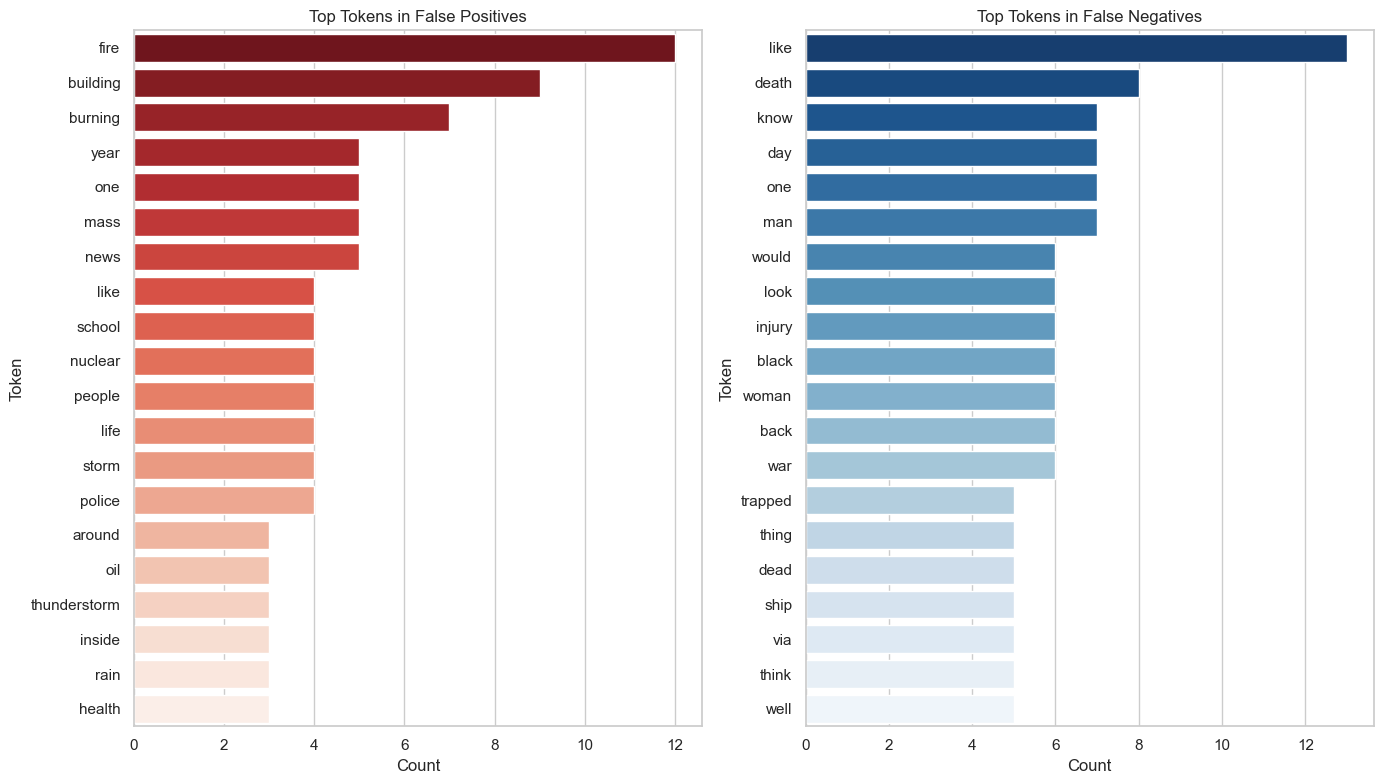

In [19]:
print("Token comparison plot")
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.barplot(data=fp_top_tokens, x="count", y="token", ax=axes[0], palette="Reds_r")
axes[0].set_title("Top Tokens in False Positives")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Token")

sns.barplot(data=fn_top_tokens, x="count", y="token", ax=axes[1], palette="Blues_r")
axes[1].set_title("Top Tokens in False Negatives")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/error_token_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
print("Probabilities")
y_val_proba = best_pipeline.predict_proba(X_val)[:, 1]
val_df["pred_proba_disaster"] = y_val_proba

false_positives = val_df[
    (val_df["true_label"] == 0) & (val_df["pred_label"] == 1)
].copy()

false_negatives = val_df[
    (val_df["true_label"] == 1) & (val_df["pred_label"] == 0)
].copy()

display(false_positives[["text", "cleaned_text", "pred_proba_disaster"]].sort_values(
    by="pred_proba_disaster", ascending=False
).head(10))

display(false_negatives[["text", "cleaned_text", "pred_proba_disaster"]].sort_values(
    by="pred_proba_disaster", ascending=True
).head(10))

Probabilities


,text,cleaned_text,pred_proba_disaster
3057,#Sismo M 1.3 - 1km NNE of The Geysers California: Time2015-08-05 23:40:21 UTC2015-08-05 16:40:21 -07:00 a... http://t.co/x6el3ySYcn #CS,sismo km nne geyser california time utc,0.850083
4376,Governor weighs parole for California school bus hijacker http://t.co/7NPBfRzEJL http://t.co/Y0kByy8nce,governor weighs parole california school bus hijacker,0.832924
5435,Maid charged with stealing Dh30000 from police officer sponsor http://t.co/y35qtVDSOH | https://t.co/qhUJAjCTR5,maid charged stealing dh police officer sponsor,0.790052
3749,I See Fire,see fire,0.784506
2773,Fascinating pics from inside North Korea. Not propaganda not devastation - just people living life. http://t.co/E2Dbcpwd9u,fascinating pic inside north korea propaganda devastation people living life,0.784190
2832,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,potus strategicpatience strategy genocide refugee idp internally displaced people horror etc,0.781092
1358,if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings,firefighter acted like cop drive around shooting flamethrower burning building,0.777616
1195,@SonofLiberty357 all illuminated by the brightly burning buildings all around the town!,illuminated brightly burning building around town,0.773650
2991,@NWSPocatello BG-16: So far brunt of storm just to our north. Grayed out w/ dust &amp; rain to N blue sky interspersed w/ clouds to S.,bg far brunt storm north grayed dust rain blue sky interspersed cloud,0.758895
4845,@CarlaChamorros HILLARY A MASS MURDERER.,hillary mass murderer,0.758312


,text,cleaned_text,pred_proba_disaster
6108,Do you feel like you are sinking in low self-image? Take the quiz: http://t.co/bJoJVM0pjX http://t.co/wHOc7LHb5F,feel like sinking low self image take quiz,0.074083
4154,You can never escape me. Bullets don't harm me. Nothing harms me. But I know pain. I know pain. Sometimes I share it. With someone like you.,never escape bullet harm nothing harm know pain know pain sometimes share someone like,0.089910
556,Black Eye 9: A space battle occurred at Star M27329 involving 1 fleets totaling 1236 ships with 7 destroyed,black eye space battle occurred star involving fleet totaling ship destroyed,0.108363
4143,@leedsrouge Love what you picked! We're playing WORTH IT by FIFTH HARM/KID INK because of you! Listen &amp; Vote: http://t.co/0wrATkA2jL,love picked playing worth fifth harm kid ink listen vote,0.109942
895,Bloody insomnia again! Grrrr!! #Insomnia,bloody insomnia grrrr insomnia,0.118630
2250,Why are you deluged with low self-image? Take the quiz: http://t.co/XsPqdOrIqj http://t.co/CQYvFR4UCy,deluged low self image take quiz,0.138725
3435,Chick masturbates a guy until she gets exploded on her face &gt; http://t.co/5QhoeHE9hf,chick masturbates guy get exploded face,0.141342
2905,I can't drown my demons they know how to swim,drown demon know swim,0.151916
6212,@PianoHands You don't know because you don't smoke. The way to make taxis and buses come is to light a cigarette to smoke while you wait.,know smoke way make taxi bus come light cigarette smoke wait,0.153796
1853,Ina Buted Girl Crush??,ina buted girl crush,0.157244


Probability distribution plot


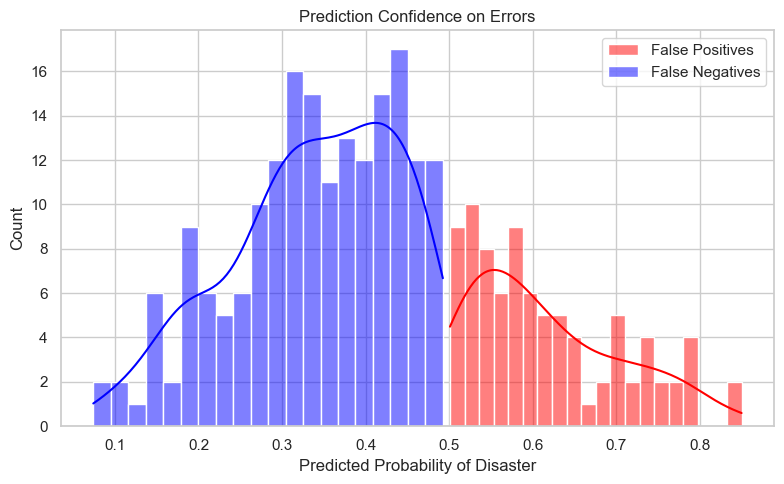

In [21]:
print("Probability distribution plot")
plt.figure(figsize=(8, 5))
sns.histplot(false_positives["pred_proba_disaster"], color="red", label="False Positives", kde=True, bins=20)
sns.histplot(false_negatives["pred_proba_disaster"], color="blue", label="False Negatives", kde=True, bins=20)
plt.title("Prediction Confidence on Errors")
plt.xlabel("Predicted Probability of Disaster")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/error_probability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
print("Sample True Positives vs False Negatives")
print("Sample true positives")
display(true_positives[["text", "cleaned_text", "keyword"]].sample(min(10, len(true_positives)), random_state=RANDOM_STATE))

print("Sample false negatives")
display(false_negatives[["text", "cleaned_text", "keyword"]].sample(min(10, len(false_negatives)), random_state=RANDOM_STATE))

Sample True Positives vs False Negatives
Sample true positives


,text,cleaned_text,keyword
6599,Woman sneaks into airplane cockpit; terrorism not suspected http://t.co/1W58Ehv9S1 http://t.co/p8Ih0hni3l,woman sneak airplane cockpit terrorism suspected,terrorism
6391,#GRupdates Pic of 16yr old PKK suicide bomber who detonated bomb in Turkey Army trench released --&gt; http://t.co/fqcDPhccg7,grupdates pic yr old pkk suicide bomber detonated bomb turkey army trench released,suicide%20bomb
4601,Traffic Collision - No Injury: I5 S at I5 S 43rd Ave offramp South Sac http://t.co/cT9ejXoLpu,traffic collision injury rd ave offramp south sac,injury
4671,Potential Storm Surge Flooding Map by National Hurricane Center http://t.co/JZWRWlVlSj \nhttp://t.co/oT3bjjhH8s,potential storm surge flooding map national hurricane center,inundation
414,Alleged East Bay serial arsonist arrested http://t.co/WR48AQTUm7,alleged east bay serial arsonist arrested,arsonist
1721,SSP East says a car AEG 061 driven by a young man collided with Akram's carhot words were exchanged n he did firing in air1bullet hit tyre,ssp east say car aeg driven young man collided akram carhot word exchanged firing air bullet hit tyre,collided
5903,Watch This Airport Get Swallowed Up By A Sandstorm In Under A Minute http://t.co/87H5MbA3N1,watch airport get swallowed sandstorm minute,sandstorm
1393,??\nWarfighting Robots Could Reduce Civilian Casualties So Calling for a Ban Now Is Premature - IEEE Spectrum http://t.co/TzR58B86qz,warfighting robot could reduce civilian casualty calling ban premature ieee spectrum,casualties
6401,#ISIS claims responsibility for Saudi suicide bombing http://t.co/jlMICJ6jE5,isi claim responsibility saudi suicide bombing,suicide%20bomber
7591,Heat wave warning aa? Ayyo dei. Just when I plan to visit friends after a year.,heat wave warning aa ayyo dei plan visit friend year,


Sample false negatives


,text,cleaned_text,keyword
5321,Pandemonium In Aba As Woman Delivers Baby Without Face (Photos).... http://t.co/lYXNjlxL8s http://t.co/CXYFqN3ue4,pandemonium aba woman delivers baby without face photo,pandemonium
6631,Signing a petition to seek mercy on a death punishment for a convivted terrorist is a job well done in India. But asking a foreign govt 1/n,signing petition seek mercy death punishment convivted terrorist job well done india asking foreign govt,terrorist
4258,@hollywarnexx mini heat wave apaz,mini heat wave apaz,heat%20wave
4902,@freddiedeboer @Thucydiplease then you have rise of Coates Charleston massacre Walter Scott and black twitter more broadly as well.,rise coates charleston massacre walter scott black twitter broadly well,massacre
2493,@binellithresa TY for the follow Go To http://t.co/UAN05TNkSW BRUTALLY ABUSED+DESOLATE&amp;LOST + HER LOVELY MUM DIES..Is it Murder?,ty follow go brutally abused desolate lost lovely mum dy murder,desolate
247,annihilating quarterstaff of annihilation,annihilating quarterstaff annihilation,annihilation
2564,5/6 will destroy Reg C competitiveness. The entire region will B over-saturated. Yes Brockton gets $12M and RegC Commonwealth PPC and,destroy reg competitiveness entire region saturated yes brockton get regc commonwealth ppc,destroy
6086,After a Few Years Afloat Pension Plans Start Sinking Again http://t.co/4cEEuzWHvf,year afloat pension plan start sinking,sinking
5069,*books a flight to Burma when country is enduring political unrest and a natural disaster* no wonder it was so cheap ay,book flight burma country enduring political unrest natural disaster wonder cheap ay,natural%20disaster
6915,@canagal Good to hear it's back.. that storm's been given you guys trouble though :( ^SJ,good hear back storm given guy trouble though sj,trouble


In [23]:
print("Sample True Negatives vs False Positives")
print("Sample true negatives")
display(true_negatives[["text", "cleaned_text", "keyword"]].sample(min(10, len(true_negatives)), random_state=RANDOM_STATE))

print("Sample false positives")
display(false_positives[["text", "cleaned_text", "keyword"]].sample(min(10, len(false_positives)), random_state=RANDOM_STATE))

Sample True Negatives vs False Positives
Sample true negatives


,text,cleaned_text,keyword
3678,@FaTality_US need a team? We need one.,need team need one,fatality
1866,Seriously have the biggest girl crush ever on Blake Lively,seriously biggest girl crush ever blake lively,crush
824,peanut butter cookie dough blizzard is ??????????????????????,peanut butter cookie dough blizzard,blizzard
1592,That sounds like a really bad idea I like Yoenis but I feel like his production could fall off a huge cliff.,sound like really bad idea like yoenis feel like production could fall huge cliff,cliff%20fall
597,FedEx no longer will transport bioterror germs http://t.co/SHrhkfj1bC via @usatoday,fedex longer transport bioterror germ via,bioterror
5337,Element of Freedom at Mirage Saturday! 21+ Ladies Free Before Midnight!' http://t.co/7hAnPcr5rK,element freedom mirage saturday lady free midnight,pandemonium
2097,A Year Later Ferguson Sees Change but Asks if ItÛªs Real http://t.co/H9vmMDEbDx,year later ferguson see change asks real,death
2088,Can't believe Ross is dead???????? @emmerdale @MikeParrActor #Emmerdale #summerfate,believe ross dead emmerdale summerfate,dead
5210,&amp; on the rare occasion I do go out I'm complete obliterated the next day. Throwing up and passing out. My body is accustomed to alcohol,rare occasion go complete obliterated next day throwing passing body accustomed alcohol,obliterated
7283,reap the whirlwind,reap whirlwind,whirlwind


Sample false positives


,text,cleaned_text,keyword
1350,I'm battling monsters I'm pulling you out of the burning buildings and you say I'll give you anything but you never come through.,battling monster pulling burning building say give anything never come,burning%20buildings
1358,if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings,firefighter acted like cop drive around shooting flamethrower burning building,burning%20buildings
2121,53 years ago this week is the anniversary of Marilyn Monroe's death RIPRIPRIP,year ago week anniversary marilyn monroe death ripriprip,death
2832,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,potus strategicpatience strategy genocide refugee idp internally displaced people horror etc,displaced
7266,PawSox owners public return from whirlwind trip to Durham - Knoxville News Sentinel http://t.co/9ckggGYvOU http://t.co/u0vdBrXfia,pawsox owner public return whirlwind trip durham knoxville news sentinel,whirlwind
3383,my school just put the evacuation alarms on accidently with 2 different trial exams happening are you kidding me,school put evacuation alarm accidently different trial exam happening kidding,evacuation
1823,@johndcgow heard this few days ago while driving and near crashed the car from laughing to much,heard day ago driving near crashed car laughing much,crashed
1195,@SonofLiberty357 all illuminated by the brightly burning buildings all around the town!,illuminated brightly burning building around town,buildings%20burning
4004,I hope it rains throughout the whole weekend I hope it floods and the portaloos become sentient.,hope rain throughout whole weekend hope flood portaloos become sentient,floods
6042,ENGLAND EAST COAST. Dogger Bank Westward. 1. Seismic survey in progress by M/V Western Regent towing a 8400 metre long cable within areaÛ_,england east coast dogger bank westward seismic survey progress western regent towing metre long cable within area,seismic


In [24]:
print("Error Tagging Helper")
false_positives["notes"] = ""
false_negatives["notes"] = ""

display(false_positives[["text", "cleaned_text", "notes"]].head(15))
display(false_negatives[["text", "cleaned_text", "notes"]].head(15))

Error Tagging Helper


,text,cleaned_text,notes
1358,if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings,firefighter acted like cop drive around shooting flamethrower burning building,
5267,@TroySlaby22 slicker than an oil spill,slicker oil spill,
5017,The 19 year old's smug face when Dorret brings out her mudslide Black Forest gateau #priceless #GBBO,year old smug face dorret brings mudslide black forest gateau priceless gbbo,
1673,That sounds about right. Our building will have a thunderstorm inside one day when the air masses collide. https://t.co/2rTQ9QmGPB,sound right building thunderstorm inside one day air mass collide,
4004,I hope it rains throughout the whole weekend I hope it floods and the portaloos become sentient.,hope rain throughout whole weekend hope flood portaloos become sentient,
3057,#Sismo M 1.3 - 1km NNE of The Geysers California: Time2015-08-05 23:40:21 UTC2015-08-05 16:40:21 -07:00 a... http://t.co/x6el3ySYcn #CS,sismo km nne geyser california time utc,
2986,Drowning in Actavis suicide,drowning actavis suicide,
3749,I See Fire,see fire,
4376,Governor weighs parole for California school bus hijacker http://t.co/7NPBfRzEJL http://t.co/Y0kByy8nce,governor weighs parole california school bus hijacker,
2951,So today I fell off a rock scraped my whole butt and nearly drowned #summer2k15,today fell rock scraped whole butt nearly drowned summer,


,text,cleaned_text,notes
6837,Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped miners starring... http://t.co/tyyfG4qQvM,hollywood movie trapped miner released chile hollywood movie trapped miner starring,
2905,I can't drown my demons they know how to swim,drown demon know swim,
1956,@XHNews We need these plants in the pacific during the cyclone seasons it would help,need plant pacific cyclone season would help,
5020,'It looks like a mudslide' poor thing! ?? #greatbritishbakeoff,look like mudslide poor thing greatbritishbakeoff,
7605,on the flip side I'm at Walmart and there is a bomb and everyone had to evacuate so stay tuned if I blow up or not,flip side walmart bomb everyone evacuate stay tuned blow,
6818,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day in September there,bomb head explosive decision dat produced dead child dead body trapped tween building day september,
6006,I agree with certain cultural appropriation things but honestly if u looked at my house it screams appropriation bc Buddhas and stuff-,agree certain cultural appropriation thing honestly looked house scream appropriation bc buddha stuff,
3441,The Dress Memes Have Officially Exploded On The Internet http://t.co/3drSmxw3cr,dress meme officially exploded internet,
6488,Aquarium Ornament Wreck Sailing Boat Sunk Ship Destroyer Fish Tank Cave Decor - Full read Û_ http://t.co/nosA8JJjiN http://t.co/WUKvdavUJu,aquarium ornament wreck sailing boat sunk ship destroyer fish tank cave decor full read,
5642,Newlyweds feed thousands of Syrian refugees instead of hosting a banquet wedding dinner - http://t.co/XZV0lT9ZZk via @smh,newlywed feed thousand syrian refugee instead hosting banquet wedding dinner via,


## Day 5 Observations

### 1. False positives
- False positives are often caused by tweets that contain strong disaster vocabulary such as `fire`, `building`, `burning`, `storm`, `nuclear`, and `mass`.
- In many of these cases, the tweet is not describing a real disaster event but instead uses disaster-related language in a figurative, conversational, historical, entertainment, or non-emergency context.
- This suggests the model is relying heavily on word-level disaster intensity rather than full semantic context.

### 2. False negatives
- False negatives often contain more ambiguous, conversational, or weakly framed language.
- Common tokens such as `like`, `know`, `day`, `one`, `would`, and `look` appear frequently, which indicates that many missed disaster tweets do not use highly explicit event wording.
- Some of these tweets mention real disaster situations, but the signal is diluted by casual phrasing, short length, or indirect wording.

### 3. Token-level takeaway
- The token analysis shows a clear asymmetry between error types.
- False positives are driven by obvious disaster words, while false negatives are often driven by vague or context-dependent language.
- This is a classic limitation of unigram TF-IDF models, which capture word presence well but do not understand nuanced context.

### 4. Confidence takeaway
- The probability distribution suggests that many false negatives are borderline cases below the default 0.5 threshold.
- This means threshold tuning may help recover recall without completely changing the model.
- At the same time, some false positives are high-confidence mistakes, which indicates that threshold tuning alone will not solve all semantic confusion.

### 5. What to try next
- Day 6 should focus on tuning the current best model rather than immediately jumping to a new architecture.
- The most useful next experiments are threshold tuning, `C` tuning for Logistic Regression, and comparing the tuned Exp 002 model against the higher-recall Exp 004 model.
- If performance plateaus after tuning, the next major improvement path would be transformer-based models.